# Phân tích dữ liệu Titanic (EDA)

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**:
    + Bộ dữ liệu dựa trên thảm họa tàu Titanic năm 1912, với hơn 1300 hành khách.
    + Các đặc điểm bao gồm thông tin cá nhân và chuyến đi: hạng vé, giới tính, tuổi, số lượng người thân, giá vé, v.v.
+ **Dữ liệu vào**:
    + Pclass (hạng vé: 1,2,3)
    + Sex (giới tính: male/female)
    + Age (tuổi)
    + SibSp (số anh chị em/vợ chồng)
    + Parch (số cha mẹ/con cái)
    + Fare (giá vé)
    + Embarked (cảng khởi hành: S/C/Q)
    + Các cột khác: Name, Ticket, Cabin (có thể drop sau)
+ **Kết quả**: Survived (sống sót: 0/1)

## 2. Import các thư viện

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Thu thập dữ liệu (Acquire Data)

In [20]:
# Load dữ liệu từ raw
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Kết hợp train và test để khám phá chung (nếu cần), nhưng chủ yếu dùng train vì có label
df_dataset = df_train.copy()  # Sử dụng train làm chính cho EDA

## 4. Khám phá dữ liệu (Explore Data)

In [21]:
print(df_dataset.shape)
df_dataset.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
df_dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
# Kiểm tra missing values
df_dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
# Kiểm tra phân bố class (Survived)
df_dataset['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

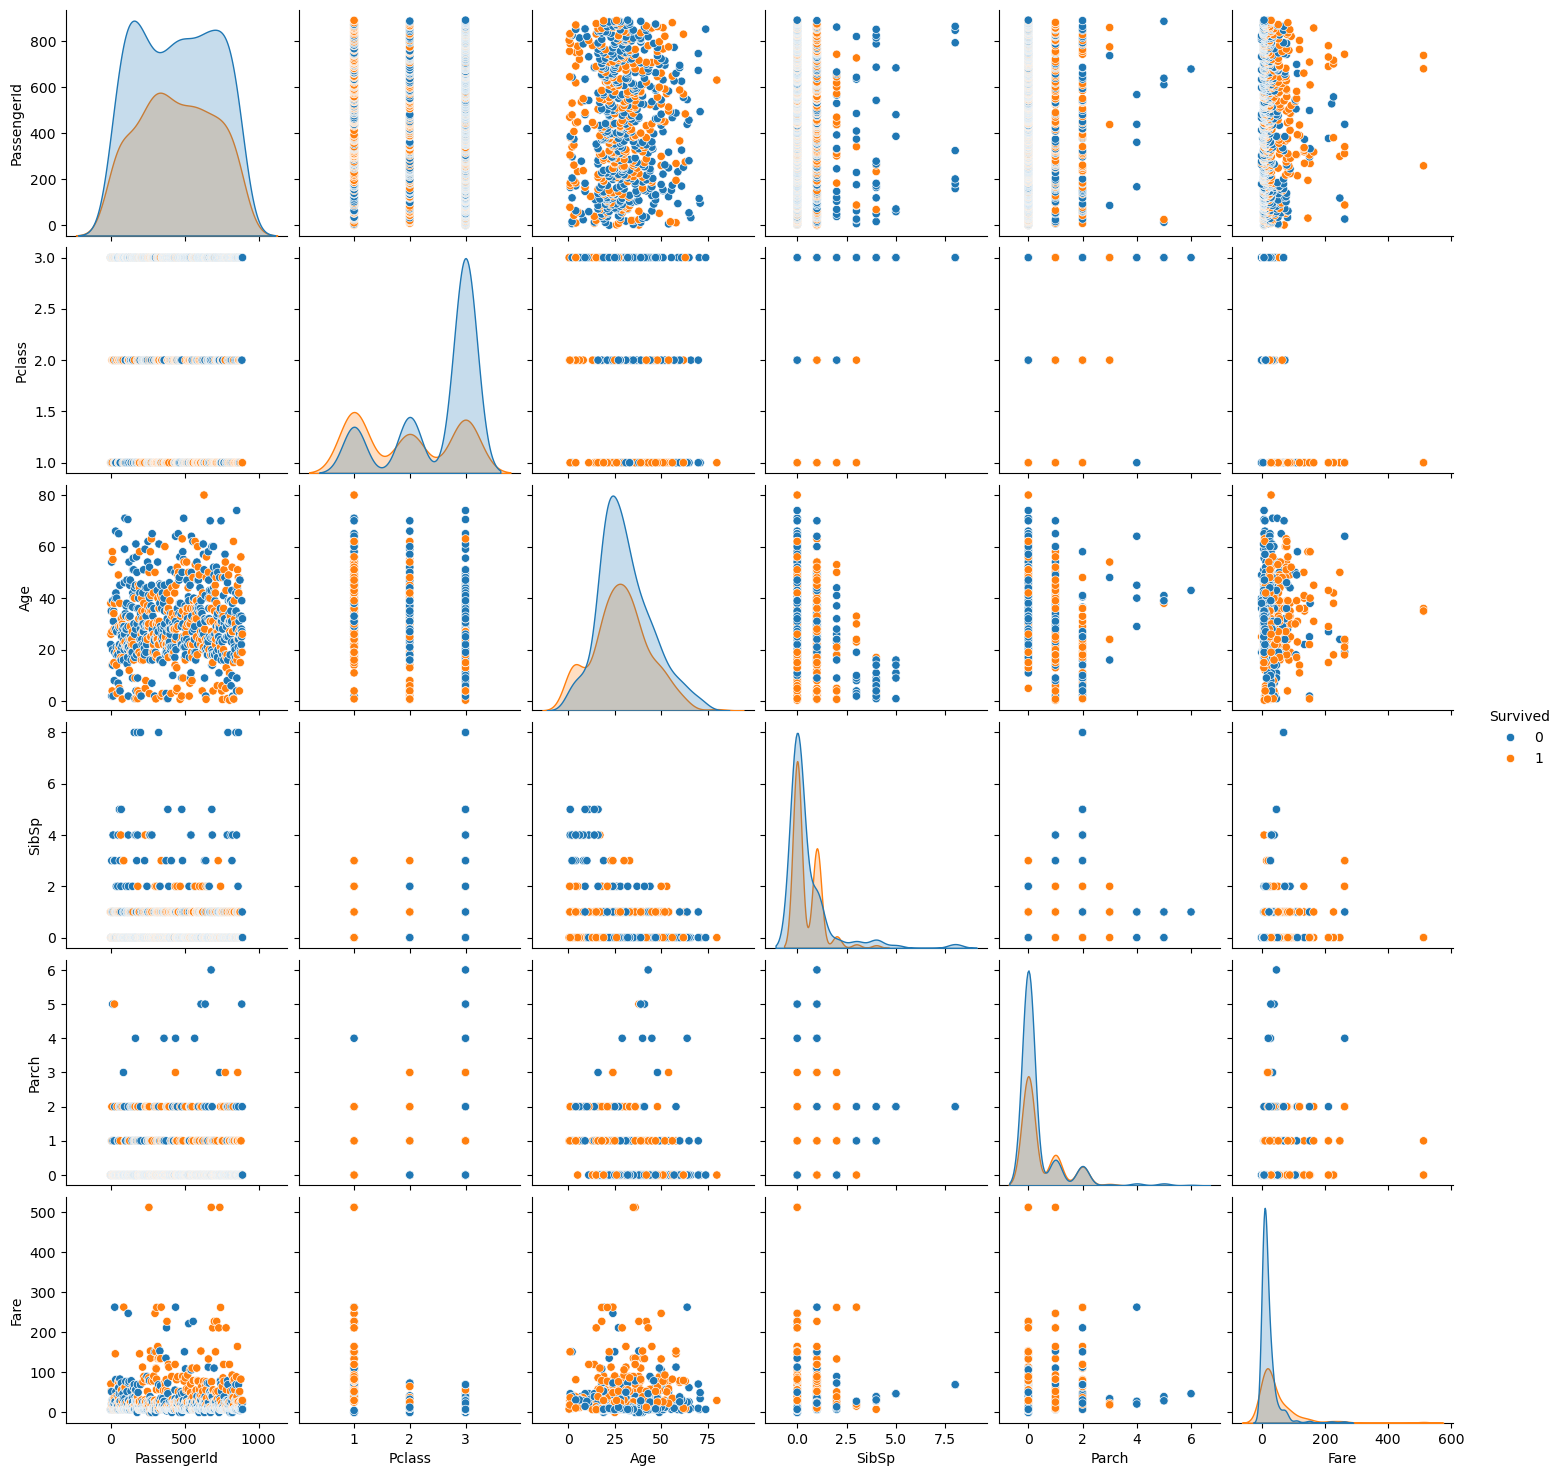

In [26]:
# seaborn
sns.pairplot(df_dataset, hue = 'Survived');

### Nhận xét hình Pairplot

- Mô tả: Biểu đồ pairplot vẽ các mối quan hệ song phương giữa các biến số (các biến số số) và tô màu theo nhãn `Survived`. Các đường chéo hiển thị phân phối từng biến.
- Quan sát chính:
  - Có sự khác biệt rõ rệt giữa các nhóm theo `Survived` ở các cặp như `Fare` và `Pclass` — hành khách ở hạng thấp hơn (Pclass lớn) thường có giá vé thấp hơn và tỷ lệ sống sót thấp hơn.
  - `Fare` có phân bố lệch phải lớn: một số hành khách trả vé rất cao (outliers) tạo đuôi dài.
  - `Age` thường phân bố rộng, có nhiều giá trị thiếu (được nhìn thấy khi các điểm rời rạc xuất hiện); trẻ em có xu hướng xuất hiện nhiều hơn trong nhóm sống sót.
- Ý nghĩa cho mô hình:
  - `Pclass` và `Fare` là các biến quan trọng và có mối liên hệ với nhãn; cần giữ và có thể kết hợp thành các feature tương tác (ví dụ: fare per class hoặc fare rank).
  - Cần xử lý outliers của `Fare` (log-transform hoặc winsorize) để giảm ảnh hưởng.
  - Thiết lập feature `is_child` (Age < 16) vì phân bố trẻ em khác biệt giữa hai nhóm.
- Bước tiếp theo đề xuất:
  - Thực hiện kiểm định thống kê đơn giản (t-test/chi-square) để xác nhận khác biệt giữa nhóm sống và chết.
  - Xử lý missing `Age` trước khi dùng mô hình (impute bằng median theo nhóm hoặc mô hình dự đoán tuổi).

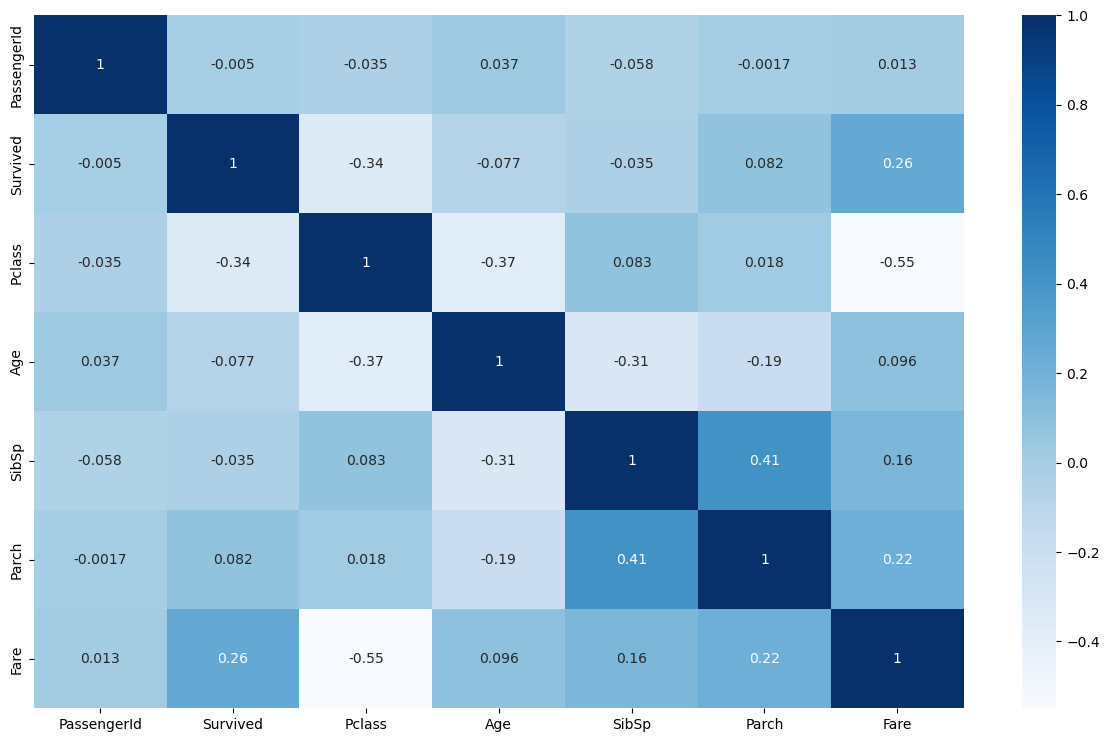

In [27]:
fig = plt.figure(figsize = (15,9))
# Use numeric columns for heatmap
numeric_df = df_dataset.select_dtypes(include=[np.number])
if numeric_df.shape[1] == 0:
    print('No numeric columns available to plot heatmap.')
else:
    sns.heatmap(numeric_df.corr(), cmap='Blues', annot = True);
    plt.show()

### Nhận xét Heatmap (ma trận tương quan)

- Mô tả: Heatmap hiển thị ma trận tương quan giữa các biến số số (numeric) sử dụng hệ màu Blues và có chú thích giá trị tương quan.
- Quan sát chính:
  - `Pclass` và `Fare` có mối tương quan âm mạnh (~-0.55): hành khách ở hạng thấp hơn có xu hướng trả vé thấp hơn.
  - `Fare` và `Survived` có tương quan dương nhỏ (~0.25): giá vé cao hơn liên quan tới xác suất sống sót cao hơn.
  - `SibSp` và `Parch` có tương quan dương vừa phải (~0.41): số anh chị em/vợ chồng thường đi cùng liên quan tới số cha mẹ/con cái.
  - Các biến khác có tương quan yếu với `Survived`, gợi ý rằng mô hình cần kết hợp nhiều biến để cải thiện dự đoán.
- Ý nghĩa cho mô hình:
  - `Pclass` là proxy cho vị trí xã hội/giàu nghèo; giữ biến này hoặc tạo embedding/one-hot khi mô hình.
  - `Fare` nên được xử lý (log-transform/khoảng hoá) để giảm ảnh hưởng của outliers.
  - Các biến có tương quan thấp không nên bị loại ngay; có thể hữu ích trong tương tác hoặc sau khi chuyển đổi.
- Bước tiếp theo đề xuất:
  - Thử chuẩn hoá các biến số và tạo các feature mới (fare bins, family_size = SibSp + Parch + 1).
  - Xem xét kiểm tra đa cộng tuyến nếu sử dụng các mô hình tuyến tính.

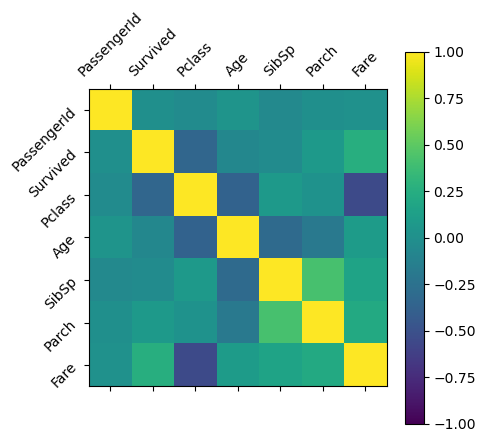

In [28]:
# matplotlib
correlations = numeric_df.corr()
plt.matshow(correlations, vmin = -1, vmax = 1), plt.colorbar()
plt.xticks(np.arange(0, len(numeric_df.columns)), rotation = 45);
plt.yticks(np.arange(0, len(numeric_df.columns)), rotation = 45);
plt.gca().set_xticklabels(list(numeric_df.columns));
plt.gca().set_yticklabels(list(numeric_df.columns));

### Nhận xét Matshow (hình ma trận tương quan matplotlib)

- Mô tả: `matshow` vẽ một ma trận tương quan tương tự heatmap nhưng không kèm annotation chi tiết; ở đây dùng để trực quan hoá tương quan giữa các cột số.
- Quan sát chính:
  - Thiết lập trục rõ ràng giúp dễ thấy mối tương quan chính: các cặp (Pclass, Fare), (Fare, Survived), (SibSp, Parch).
  - Các mối tương quan nhỏ có thể xuất hiện do sự hiện diện của outliers hoặc dữ liệu bị lệch.
- Ý nghĩa cho mô hình:
  - Hỗ trợ xác nhận các biến đã xem trong heatmap; dùng ảnh này làm bản kiểm tra nhanh khi thay đổi biến số.
- Bước tiếp theo đề xuất:
  - Đồng bộ với heatmap: nếu thêm/removing numerical features, cập nhật ma trận tương quan để xem biến đổi.
  - Thực hiện phân tích thêm cho các biến có tương quan không mong đợi (ví dụ kiểm tra theo nhóm `Pclass` hoặc `Embarked`).

Từ bản đồ nhiệt trên, chúng ta thấy rằng Pclass và Fare có mối tương quan âm cao, Fare và Survived có mối tương quan dương, cũng như SibSp và Parch có mối tương quan liên quan đến họ.

Các cặp tính chất có độ tương đồng cao:
+ (Pclass, Fare) = -0.549 (âm cao)
+ (Fare, Survived) = 0.257
+ (SibSp, Parch) = 0.415

##### Histograms and distributions (Biểu đồ tần suất và phân phối)

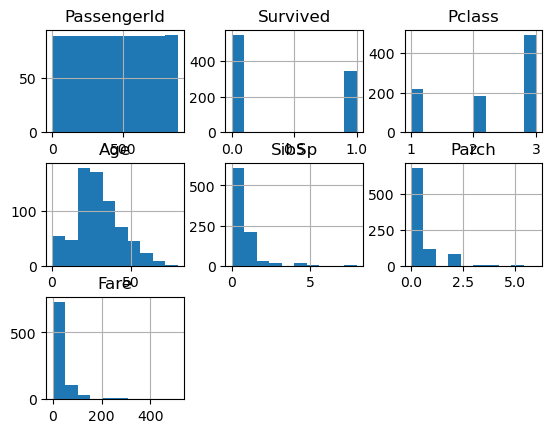

In [29]:
df_dataset.hist();

### Nhận xét Histograms (phân phối các biến số)

- Mô tả: `df_dataset.hist()` vẽ histogram cho tất cả các biến số số trong dataframe (ví dụ `Age`, `Fare`, `SibSp`, `Parch`).
- Quan sát chính:
  - `Fare` có phân bố lệch phải mạnh với vài outliers rất lớn.
  - `Age` có phân bố tập trung ở người trưởng thành (những năm 20-40), với một số trẻ em và nhiều giá trị missing trước khi imputation.
  - `SibSp` và `Parch` có phân bố nhiều giá trị 0, chứng tỏ nhiều hành khách đi một mình.
- Ý nghĩa cho mô hình:
  - Cần xử lý phân bố lệch của `Fare` (log-transform) và xử lý outliers trước khi đưa vào mô hình.
  - `SibSp` và `Parch` có thể được kết hợp thành `family_size` và chuyển thành categorical (solo, small, large).
- Bước tiếp theo đề xuất:
  - Áp dụng log(1+Fare) và vẽ lại histogram để kiểm tra sự đối xứng.
  - Điền missing `Age` bằng phương pháp phù hợp (median hoặc dự báo) và kiểm tra phân phối sau imputation.

##### Correlation with classification label (Tương quan với nhãn phân loại)

<Axes: xlabel='Survived', ylabel='Fare'>

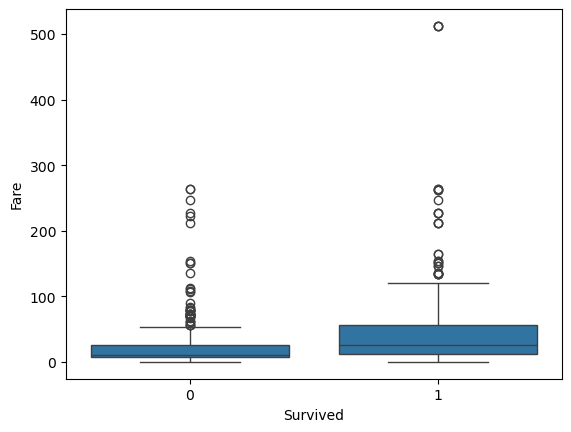

In [30]:
# seaborn
sns.boxplot(x='Survived', y='Fare', data=df_dataset)

### Nhận xét Boxplot (Fare theo Survived)

- Mô tả: Boxplot cho thấy phân bố `Fare` tách theo nhãn `Survived` (0: chết, 1: sống). Hiển thị median, IQR và outliers.
- Quan sát chính:
  - Nhóm sống (`Survived=1`) có median `Fare` cao hơn so với nhóm chết (`Survived=0`), phù hợp với tương quan dương đã thấy.
  - Có nhiều outliers ở cả hai nhóm, nhưng đặc biệt trong nhóm sống có vài giá vé rất lớn (có thể là hành khách VIP hoặc đặt cabin riêng).
  - IQR của nhóm sống có vẻ lớn hơn, cho thấy sự phân bố giá vé đa dạng hơn.
- Ý nghĩa cho mô hình:
  - `Fare` là biến phân biệt; median cao hơn trong nhóm sống cho thấy giá vé có thể là proxy cho khả năng được cứu.
  - Outliers có thể ảnh hưởng đến trọng số mô hình — cân nhắc log-transform hoặc cắt bớt outliers.
- Bước tiếp theo đề xuất:
  - Vẽ boxplot trên log(1+Fare) để kiểm tra phân bố sau biến đổi.
  - Kiểm tra `Fare` theo `Pclass` và `Embarked` để hiểu nguồn gốc outliers.

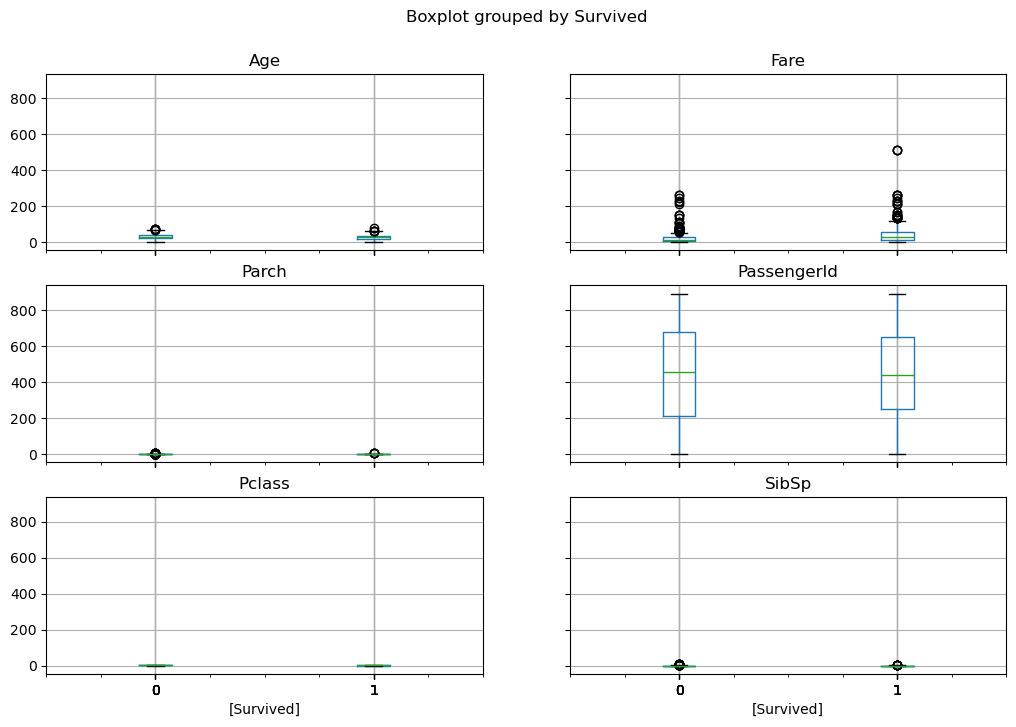

In [31]:
df_dataset.boxplot(by="Survived", figsize=(12, 8));

### Nhận xét Boxplot (theo nhóm Survived, pandas)

- Mô tả: Biểu đồ boxplot do pandas vẽ tương tự, hiển thị các biến số số phân theo nhãn (mặc định). Ở đây nó là hình tổng quan các biến số.
- Quan sát chính:
  - Xác nhận các quan sát ở boxplot `Fare` trước đó: sự khác biệt median giữa hai nhóm.
  - Các biến như `Age`, `Fare` có nhiều giá trị ngoại lai (outliers).
  - Một số biến có phân bố rất tập trung (ví dụ `SibSp`/`Parch`), cho thấy nhiều giá trị 0.
- Ý nghĩa cho mô hình:
  - Biểu đồ tổng quan hữu ích để xác định biến nào cần scale/log.
  - Các biến có range khác nhau cần chuẩn hoá trước khi dùng các mô hình khoảng cách (kNN, SVM). 
- Bước tiếp theo đề xuất:
  - Chuẩn hoá (StandardScaler/MinMax) các biến số trước khi huấn luyện.
  - Tạo báo cáo outliers cụ thể (số lượng, ngưỡng) để quyết định cắt hay winsorize.

<Axes: xlabel='Survived', ylabel='Age'>

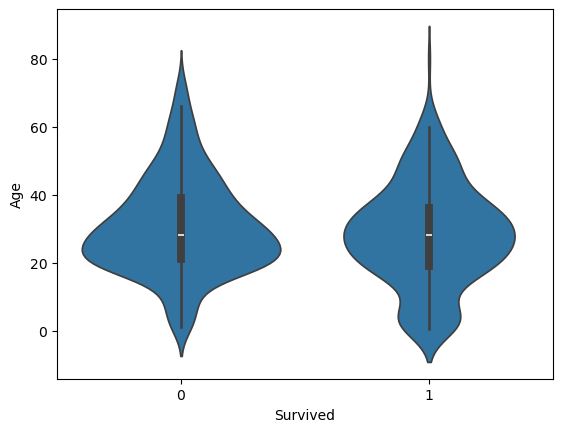

In [32]:
# seaborn
sns.violinplot(x='Survived', y='Age', data=df_dataset)

### Nhận xét Violinplot (Age theo Survived)

- Mô tả: Violinplot kết hợp boxplot và KDE để hiển thị phân phối `Age` tách theo `Survived`.
- Quan sát chính:
  - Có xu hướng trẻ em (tuổi nhỏ) xuất hiện tỷ lệ sống cao hơn; mật độ ở phần tuổi nhỏ dày hơn ở nhóm `Survived=1`.
  - Ở các nhóm tuổi trung niên, mật độ phân bố giữa hai nhãn gần nhau nhưng có sự khác biệt nhẹ.
  - `Age` có nhiều giá trị thiếu; phân bố sau imputation có thể thay đổi.
- Ý nghĩa cho mô hình:
  - `Age` là biến dự báo quan trọng, đặc biệt khi kết hợp với `Pclass` và `Sex` (ví dụ: phụ nữ và trẻ em được cứu trước).
  - Nên tạo feature tương tác như `Sex*AgeGroup` hoặc `is_child`.
- Bước tiếp theo đề xuất:
  - Impute `Age` cẩn thận (theo `Pclass` & `Sex`), sau đó vẽ lại violinplot để kiểm tra thay đổi.
  - Thử phân nhóm tuổi (bins) và kiểm tra tỷ lệ sống theo từng nhóm.

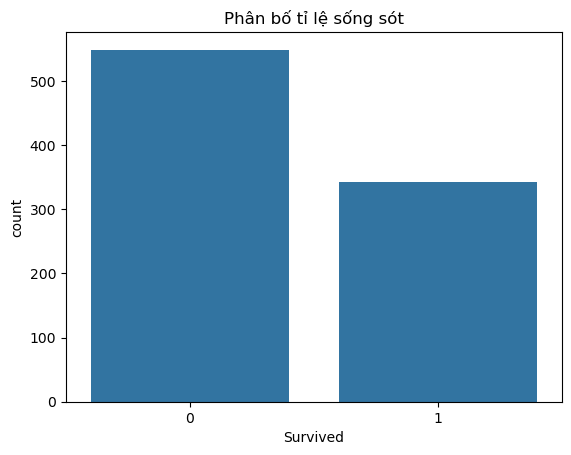

In [33]:
sns.countplot(x='Survived', data=df_train)
plt.title('Phân bố tỉ lệ sống sót')
plt.show()

### Nhận xét Countplot (Phân bố tỉ lệ sống sót)

- Mô tả: Biểu đồ đếm số lượng hành khách theo nhãn `Survived` (0: Không sống sót, 1: Sống sót).
- Quan sát chính:
  - Số lượng không sống sót (0) cao hơn sống sót (1), khoảng 549 so với 342, cho thấy tỷ lệ sống sót tổng thể khoảng 38%.
  - Dữ liệu hơi imbalance, nhưng không quá nghiêm trọng.
- Ý nghĩa cho mô hình:
  - Cần xem xét xử lý imbalance nếu mô hình bị bias (ví dụ: sử dụng SMOTE hoặc class_weight).
  - Đây là baseline để so sánh tỷ lệ sống sót theo các biến khác.
- Bước tiếp theo đề xuất:
  - Tính tỷ lệ sống sót chính xác và so sánh với các nhóm (ví dụ: theo `Pclass` hoặc `Sex`).

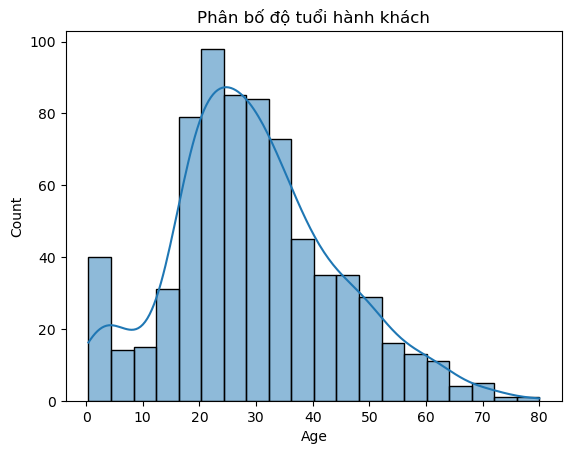

In [34]:
sns.histplot(df_train['Age'].dropna(), kde=True)
plt.title('Phân bố độ tuổi hành khách')
plt.show()

### Nhận xét Histplot (Phân bố độ tuổi hành khách)

- Mô tả: Biểu đồ histogram với KDE hiển thị phân bố độ tuổi (`Age`), loại bỏ giá trị NaN.
- Quan sát chính:
  - Độ tuổi tập trung chủ yếu từ 20-40 tuổi, với đỉnh ở khoảng 25-30 tuổi.
  - Có một số trẻ em (tuổi <10) và người cao tuổi (>60), nhưng mật độ thấp hơn.
  - Phân bố hơi lệch phải (right-skewed), với đuôi dài về phía tuổi cao.
- Ý nghĩa cho mô hình:
  - `Age` là biến liên tục quan trọng, có thể ảnh hưởng đến tỷ lệ sống sót (trẻ em và người già có thể khác biệt).
  - Skewness có thể cần transform (ví dụ: log) để cải thiện mô hình.
- Bước tiếp theo đề xuất:
  - Impute giá trị thiếu cho `Age` (ví dụ: median theo `Pclass` và `Sex`), rồi vẽ lại để kiểm tra.
  - Phân nhóm tuổi thành bins (ví dụ: child, adult, senior) để phân tích sâu hơn.

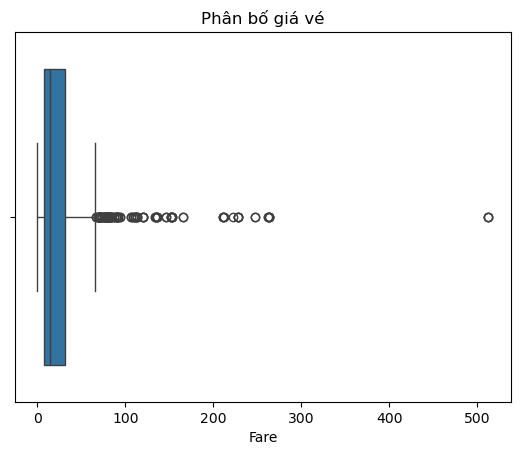

In [35]:
sns.boxplot(x=df_train['Fare'])
plt.title('Phân bố giá vé')
plt.show()

### Nhận xét Boxplot (Phân bố giá vé)

- Mô tả: Boxplot hiển thị phân bố giá vé (`Fare`), bao gồm median, quartiles và outliers.
- Quan sát chính:
  - Giá vé trung vị khoảng 14-15, nhưng có nhiều outliers cao (giá vé >100, lên đến >500).
  - Phân bố rất lệch phải (right-skewed), với hầu hết giá vé thấp (<50).
- Ý nghĩa cho mô hình:
  - `Fare` liên quan đến `Pclass` (hạng vé cao giá thấp hơn), có thể là proxy cho địa vị xã hội.
  - Outliers có thể ảnh hưởng đến mô hình; cần xem xét log-transform hoặc winsorizing.
- Bước tiếp theo đề xuất:
  - Vẽ boxplot theo `Pclass` để thấy sự khác biệt rõ hơn.
  - Kiểm tra correlation giữa `Fare` và `Survived`.

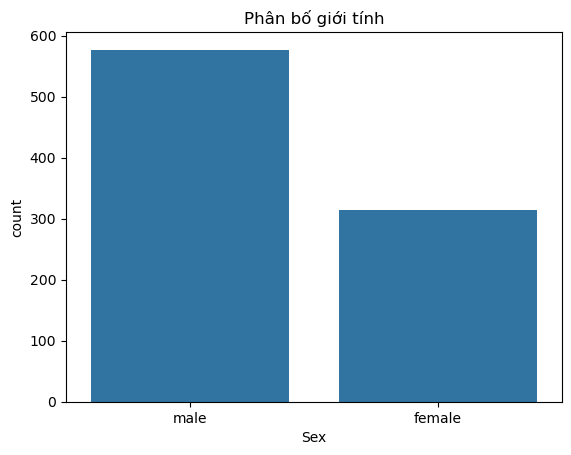

In [36]:
sns.countplot(x='Sex', data=df_train)
plt.title('Phân bố giới tính')
plt.show()

### Nhận xét Countplot (Phân bố giới tính)

- Mô tả: Biểu đồ đếm số lượng hành khách theo giới tính (`Sex`: male/female).
- Quan sát chính:
  - Nam giới chiếm đa số (khoảng 577), nữ giới ít hơn (khoảng 314).
- Ý nghĩa cho mô hình:
  - Giới tính là yếu tố quan trọng trong thảm họa Titanic (phụ nữ được ưu tiên cứu).
  - Có thể tạo feature dummy cho `Sex`.
- Bước tiếp theo đề xuất:
  - So sánh tỷ lệ sống sót theo giới tính để xác nhận xu hướng.

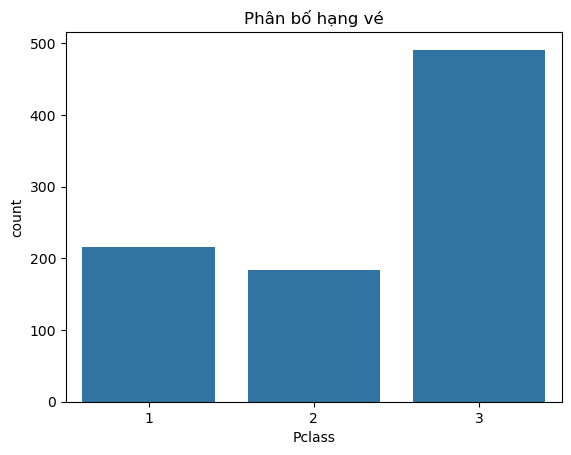

In [37]:
sns.countplot(x='Pclass', data=df_train)
plt.title('Phân bố hạng vé')
plt.show()

### Nhận xét Countplot (Phân bố hạng vé)

- Mô tả: Biểu đồ đếm số lượng hành khách theo hạng vé (`Pclass`: 1,2,3).
- Quan sát chính:
  - Hạng 3 chiếm đa số (khoảng 491), hạng 1 và 2 ít hơn (216 và 184).
- Ý nghĩa cho mô hình:
  - `Pclass` phản ánh địa vị xã hội, có thể ảnh hưởng mạnh đến sống sót (hạng cao hơn tỷ lệ sống cao hơn).
  - Sử dụng như biến categorical.
- Bước tiếp theo đề xuất:
  - Vẽ barplot tỷ lệ sống sót theo `Pclass`.

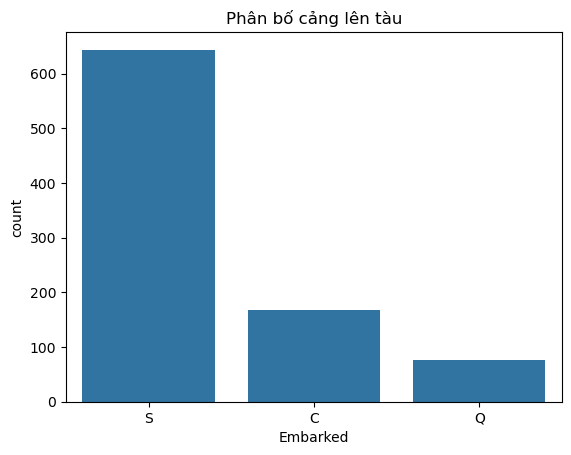

In [38]:
sns.countplot(x='Embarked', data=df_train)
plt.title('Phân bố cảng lên tàu')
plt.show()

### Nhận xét Countplot (Phân bố cảng lên tàu)

- Mô tả: Biểu đồ đếm số lượng hành khách theo cảng khởi hành (`Embarked`: S/C/Q).
- Quan sát chính:
  - Cảng S chiếm đa số (khoảng 644), C và Q ít hơn (168 và 77).
  - Có 2 giá trị thiếu.
- Ý nghĩa cho mô hình:
  - Có thể liên quan đến địa vị kinh tế; cần kiểm tra correlation với `Pclass`.
- Bước tiếp theo đề xuất:
  - Impute giá trị thiếu (mode = S), rồi kiểm tra tỷ lệ sống sót theo `Embarked`.

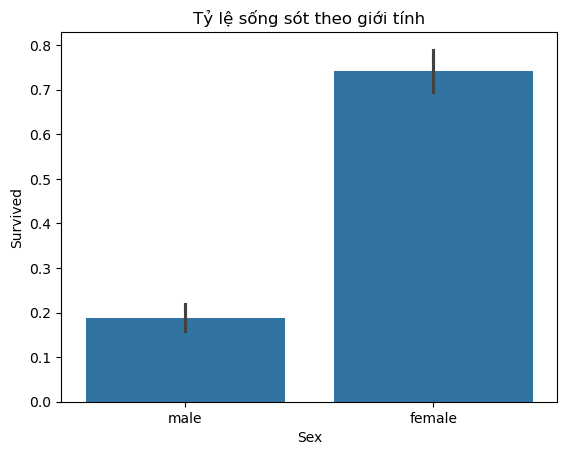

In [39]:
sns.barplot(x='Sex', y='Survived', data=df_train)
plt.title('Tỷ lệ sống sót theo giới tính')
plt.show()

### Nhận xét Barplot (Tỷ lệ sống sót theo giới tính)

- Mô tả: Barplot hiển thị tỷ lệ sống sót trung bình theo giới tính.
- Quan sát chính:
  - Nữ giới có tỷ lệ sống sót cao hơn nam giới (khoảng 74% so với 19%).
- Ý nghĩa cho mô hình:
  - `Sex` là biến dự báo mạnh; nên ưu tiên trong feature selection.
- Bước tiếp theo đề xuất:
  - Kết hợp với `Pclass` (ví dụ: crosstab hoặc heatmap).

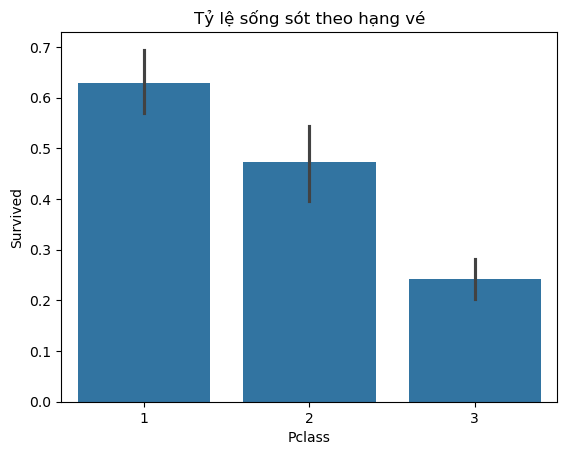

In [40]:
sns.barplot(x='Pclass', y='Survived', data=df_train)
plt.title('Tỷ lệ sống sót theo hạng vé')
plt.show()

### Nhận xét Barplot (Tỷ lệ sống sót theo hạng vé)

- Mô tả: Barplot hiển thị tỷ lệ sống sót trung bình theo hạng vé.
- Quan sát chính:
  - Hạng 1 cao nhất (khoảng 63%), hạng 3 thấp nhất (khoảng 24%).
- Ý nghĩa cho mô hình:
  - `Pclass` là proxy cho địa vị, ảnh hưởng lớn đến sống sót.
- Bước tiếp theo đề xuất:
  - Kiểm tra interaction với `Fare` hoặc `Age`.

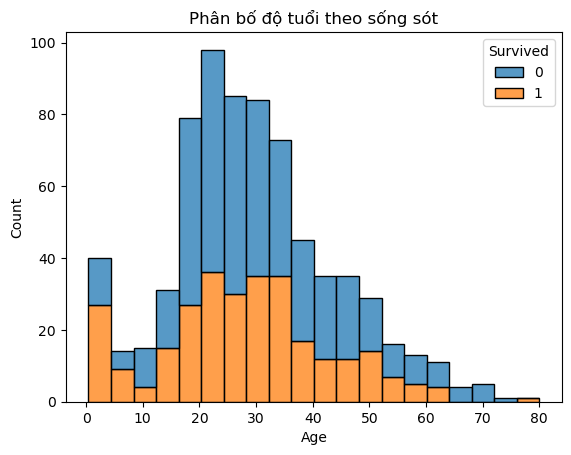

In [41]:
sns.histplot(data=df_train, x='Age', hue='Survived', multiple='stack')
plt.title('Phân bố độ tuổi theo sống sót')
plt.show()

### Nhận xét Histplot (Phân bố độ tuổi theo sống sót)

- Mô tả: Histogram stacked hiển thị phân bố tuổi theo `Survived`.
- Quan sát chính:
  - Trẻ em (<10 tuổi) có tỷ lệ sống sót cao hơn.
  - Ở tuổi trung niên (20-40), số không sống sót chiếm ưu thế.
- Ý nghĩa cho mô hình:
  - Xác nhận `Age` quan trọng; có thể tạo feature `is_child`.
- Bước tiếp theo đề xuất:
  - Impute `Age` và vẽ lại.

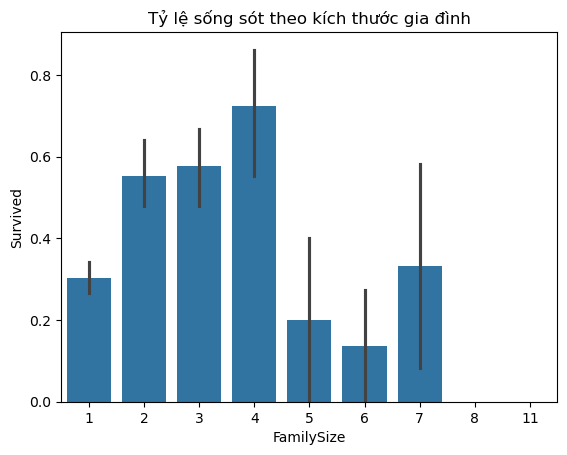

In [42]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
sns.barplot(x='FamilySize', y='Survived', data=df_train)
plt.title('Tỷ lệ sống sót theo kích thước gia đình')
plt.show()

### Nhận xét Barplot (Tỷ lệ sống sót theo kích thước gia đình)

- Mô tả: Barplot hiển thị tỷ lệ sống sót theo `FamilySize` (SibSp + Parch + 1).
- Quan sát chính:
  - Gia đình nhỏ (2-4 người) có tỷ lệ sống sót cao hơn; gia đình lớn (>5) hoặc đi một mình thấp hơn.
- Ý nghĩa cho mô hình:
  - Tạo feature mới `FamilySize` để capture mối quan hệ gia đình.
- Bước tiếp theo đề xuất:
  - Kiểm tra outliers và phân nhóm (small, medium, large family).

In [43]:
# Lưu data trung gian
df_train.to_csv('../data/interim/train_eda.csv', index=False)
df_test.to_csv('../data/interim/test_eda.csv', index=False)
print("Data saved to interim/")

Data saved to interim/


# Kết thúc

In [44]:
import os
import subprocess
from pathlib import Path

nb_dir = Path(__file__).resolve().parent if '__file__' in globals() else Path('.')

nb_dir = nb_dir if nb_dir.exists() else Path('.')
nb_path = nb_dir / 'eda.ipynb'
out_path = nb_dir / 'eda.html'

if out_path.exists():
    print(f'Removing existing file: {out_path}')
    out_path.unlink()

cmd = ['jupyter', 'nbconvert', str(nb_path), '--to', 'html']
print('Running:', ' '.join(cmd))
try:
    subprocess.run(cmd, check=True)
    print('Export complete:', out_path)
except subprocess.CalledProcessError as e:
    print('nbconvert failed with returncode', e.returncode)
    print('Ensure jupyter is available in the PATH of the environment running this notebook.')

Removing existing file: eda.html
Running: jupyter nbconvert eda.ipynb --to html
Export complete: eda.html
